### Baldocchi & Rao (1995) — advection comparison

Reproduces the advection experiment from Baldocchi & Rao (1995):
a potato field (irrigated) downwind of a sagebrush desert, eastern Oregon
(June 1992, Days 154 & 164).

**This notebook uses the current `AdvectionParams`–based solver** from
`src/sutton/`, replacing the legacy `Params`/dict approach in the original
notebook.

#### Site parameters (from paper)
| quantity | fallow (desert) | crop (potato) |
|---|---|---|
| $H$ (W $\text{m}^{-2}$) | 350 | 50 |
| $LE$ (W $\text{m}^{-2}$) | 100 | 500 |
| $R_n$ (W $\text{m}^{-2}$) | 480 | 580 |
| $G$ (W $\text{m}^{-2}$) | 30 | 30 |
| $z_{0m}$ (m) | 0.005–0.05 | 0.05 |
| canopy height $h$ | — | 2.3 m (potato) |

Meteorological forcing: $SW_{in}$ = 700 W $\text{m}^{-2}$, $T_a$ = 16 °C, $Q_a$ = 5 g m$^{-3}$.

#### Key figure
**Normalised ET vs fetch** — comparison with Fig. 6 of Baldocchi & Rao (1995).


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

sys.path.insert(0, "/Users/octaviacrompton/Projects/sutton_advection/src")

from sutton import (
    AdvectionParams,
    thomas,
    our_central_difference,
    no_central_difference,
    SIGMA_SB, CP_AIR, RHO_AIR, LV, LV_G, RV,
)


In [29]:
sigma_sb = SIGMA_SB
cp_air   = CP_AIR
rho_air  = RHO_AIR
Lv       = LV
Lv_g     = LV_G
Rv       = RV


### Boundary conditions from Baldocchi & Rao (1995)

Energy fluxes and meteorological forcing taken directly from the paper.
Surface temperatures and moisture concentrations are derived via log-law
inversion at $z_{0h}$; albedos follow from the radiation balance using
those surface temperatures.  Inverting directly at $z_{0h}$ (rather than
at a grid level and rescaling afterward) ensures the $\varepsilon\sigma T^4$

term in the radiation balance is consistent with the solver BC.

In [30]:
# ── Observed energy fluxes (W m⁻²) ───────────────────────────────────────
H_f_obs  = 350.0    # fallow sensible heat
LE_f_obs = 100.0    # fallow latent heat
H_c_obs  =  50.0    # crop sensible heat
LE_c_obs = 500.0    # crop latent heat

Rn_f = 480.0   # fallow net radiation
Rn_c = 580.0   # crop net radiation
G    =  30.0   # ground heat flux (both surfaces)

# ── Meteorological forcing ────────────────────────────────────────────────
SW_in     = 700.0    # incoming shortwave (W m⁻²)
T_a       =  16.0    # air temperature (°C)
Q_a       =   5.0    # ambient vapour concentration (g m⁻³)

# ── Surface properties ────────────────────────────────────────────────────
epsilon_a = 0.90     # atmospheric emissivity
epsilon_f = 0.95     # fallow emissivity
epsilon_c = 0.95     # crop emissivity
zom_f     = 0.05     # fallow momentum roughness (m)
zom_c     = 0.05     # crop momentum roughness (m)
h_canopy  = 2.3      # potato canopy height (m)


In [ ]:
# ── Derive surface T, Q, and albedos ─────────────────────────────────────
# Log-law inversion at z0h + radiation balance for albedos.
# Using z0h as the log-law base ensures the surface T used in the
# radiation balance (ε σ T⁴) is consistent with the solver BC.

# Mean wind and friction velocities
Ubar_4 = 3.76 * 2   # Baldocchi (1995) reports U₄ = 3.76 m/s; ×2 corrects to ~8 m ABL wind
ustar_f = 0.4 * Ubar_4 / np.log(4 / zom_f)
ustar_c = 0.4 * Ubar_4 / np.log(4 / zom_c)

# Scalar roughness = z0m / 5
zoh_f = zom_f / 5
zoh_c = zom_c / 5

# Domain height for log-law reference
z_h = 100.0

# Kinematic fluxes
SH_f_kin = H_f_obs  / (cp_air * rho_air)   # K m s⁻¹
SH_c_kin = H_c_obs  / (cp_air * rho_air)
LE_f_kin = LE_f_obs / Lv_g                  # g m⁻² s⁻¹
LE_c_kin = LE_c_obs / Lv_g

T_a_K = T_a + 273.15
k = 0.4

# Log-law inversion at z0h (surface temperature in K)
T_sf_K = T_a_K + SH_f_kin / (k * ustar_f) * np.log(z_h / zoh_f)
T_sc_K = T_a_K + SH_c_kin / (k * ustar_c) * np.log(z_h / zoh_c)

# Log-law inversion at z0h (surface moisture in g m⁻³)
Q_f_sol = Q_a + LE_f_kin / (k * ustar_f) * np.log(z_h / zoh_f)
Q_c_sol = Q_a + LE_c_kin / (k * ustar_c) * np.log(z_h / zoh_c)

# Albedos from radiation balance:  Rn = SW_in(1-α) + ε_a σ T_a⁴ - ε_s σ T_s⁴
alpha_f_sol = 1 - (Rn_f - epsilon_a*sigma_sb*T_a_K**4 + epsilon_f*sigma_sb*T_sf_K**4) / SW_in
alpha_c_sol = 1 - (Rn_c - epsilon_a*sigma_sb*T_a_K**4 + epsilon_c*sigma_sb*T_sc_K**4) / SW_in

# Convert to °C for solver BCs
T_sf_C = T_sf_K - 273.15
T_sc_C = T_sc_K - 273.15

print("── Derived boundary conditions ──")
print(f"  T_sf = {T_sf_C:.2f} °C,   T_sc = {T_sc_C:.2f} °C")
print(f"  Q_f  = {Q_f_sol:.3f} g/m³,  Q_c  = {Q_c_sol:.3f} g/m³")
print(f"  α_f  = {alpha_f_sol:.4f},   α_c  = {alpha_c_sol:.4f}")
print(f"  u*_f = {ustar_f:.4f} m/s,  u*_c = {ustar_c:.4f} m/s")


── Derived boundary conditions ──
  T_sf = 25.73 °C,   T_sc = 17.39 °C
  Q_f  = 6.380 g/m³,  Q_c  = 11.902 g/m³
  α_f  = 0.2098,   α_c  = 0.1327
  u*_f = 0.6864 m/s,  u*_c = 0.6864 m/s


### AdvectionParams setup

Build the parameter object using the derived boundary conditions.
The domain is 20 km long with dx = 5 m, dz = 0.2 m, Hmax = 100 m — matching
the original notebook's grid.


In [32]:
p = AdvectionParams(
    ustar_f  = ustar_f,
    ustar_c  = ustar_c,
    T_sf     = T_sf_C,
    T_sc     = T_sc_C,
    T_a      = T_a,
    Q_f      = Q_f_sol,
    Q_c      = Q_c_sol,
    Q_a      = Q_a,
    Hmax     = 100.0,
    Lx       = 20000.0,
    dz       = 0.2,
    dx       = 5.0,
    zom_f    = zom_f,
    zom_c    = zom_c,
    h_c_opt  = h_canopy,
    lm_option = 'kz',
    SW_in    = SW_in,
    alpha_f  = alpha_f_sol,
    alpha_c  = alpha_c_sol,
    epsilon_a = epsilon_a,
    epsilon_f = epsilon_f,
    epsilon_c = epsilon_c,
    G         = G,
)

print(f"Grid: nx={p.nx}, nz={p.nz}, dx={p.dx}, dz={p.dz}")
print(f"Domain: Lx={p.Lx} m, Hmax={p.Hmax} m")
print(f"T_sf={p.T_sf:.2f}°C, T_sc={p.T_sc:.2f}°C, T_a={p.T_a}°C")
print(f"Q_f={p.Q_f:.3f}, Q_c={p.Q_c:.3f}, Q_a={p.Q_a} g/m³")


Grid: nx=4001, nz=500, dx=5.0, dz=0.2
Domain: Lx=20000.0 m, Hmax=100.0 m
T_sf=25.73°C, T_sc=17.39°C, T_a=16.0°C
Q_f=6.380, Q_c=11.902, Q_a=5.0 g/m³


### Solver functions

The same implicit advection solver used in the general notebook. Marches
temperature and humidity downwind using Thomas algorithm + mixing-length
eddy diffusivity.


In [ ]:
def integrate_H2O_step(p, Q_up, A, B, C):
    m, dz, z = int(p.nz), p.dz, p.z
    AA1, AA2 = -A * B, -C * B
    AA3, AA4 = 1 / p.dx, Q_up / p.dx

    upd = AA1 / dz**2 + AA2 / (2*dz)
    dia = -2*AA1 / dz**2 + AA3
    lod = AA1 / dz**2 - AA2 / (2*dz)
    co = np.full(m, 0.0); co[:] = AA4

    lod[0] = lod[-1] = 0; dia[0] = dia[-1] = 1; upd[0] = upd[-1] = 0
    co[0] = p.Q_c; co[-1] = p.Q_a

    Q1 = thomas(lod, dia, upd, co)
    dQdz = no_central_difference(Q1, z)
    return Q1, -A / z * dQdz


def integrate_T_step(p, T_up, A, B, C):
    m, dz, z = int(p.nz), p.dz, p.z
    AA1, AA2 = -A * B, -C * B
    AA3, AA4 = 1 / p.dx, T_up / p.dx

    upd = AA1 / dz**2 + AA2 / (2*dz)
    dia = -2*AA1 / dz**2 + AA3
    lod = AA1 / dz**2 - AA2 / (2*dz)
    co = np.full(m, 0.0); co[:] = AA4

    lod[0] = lod[-1] = 0; dia[0] = dia[-1] = 1; upd[0] = upd[-1] = 0
    co[0] = p.T_sc; co[-1] = p.T_a

    T1 = thomas(lod, dia, upd, co)
    dTdz = no_central_difference(T1, z)
    return T1, -(A / z) * dTdz


def uniform_Q(p):
    z, k = p.z, p.k
    FQ_f = p.ustar_f * k * (p.Q_f - p.Q_a) / np.log(p.Hmax / z[0])
    Qup = p.Q_f - (FQ_f / (k * p.ustar_f)) * np.log(z / z[0])
    U = (p.ustar_f / k) * np.log(z / (p.zom_c + 1e-9))
    A = p.lm * p.ustar_c; B = 1.0 / U
    C = our_central_difference(A, p.dz)

    Q1 = Qup.copy()
    Q_out  = np.zeros((p.nx, p.nz))
    FQ_out = np.zeros((p.nx, p.nz))
    Q_out[0] = Q1
    for i in range(p.nx):
        Q2, Fq = integrate_H2O_step(p, Q1, A, B, C)
        Q_out[i] = Q2; FQ_out[i] = Fq; Q1 = Q2
    return Q_out, FQ_out


def uniform_T(p):
    z, k = p.z, p.k
    wT = -(p.T_a - p.T_sf) * k * p.ustar_f / np.log(p.Hmax / z[0])
    Tup = p.T_sf - (wT / (k * p.ustar_f)) * np.log(z / z[0])
    U = (p.ustar_f / k) * np.log(z / (p.zom_c + 1e-9))
    A = p.lm * p.ustar_c; B = 1.0 / U
    C = our_central_difference(A, p.dz)

    T1 = Tup.copy()
    T_out  = np.zeros((p.nx, p.nz))
    FT_out = np.zeros((p.nx, p.nz))
    T_out[0] = T1
    for i in range(p.nx):
        T2, FT = integrate_T_step(p, T1, A, B, C)
        T_out[i] = T2; FT_out[i] = FT; T1 = T2
    return T_out, FT_out


def get_upwind_fluxQ(p):
    z, k = p.z, p.k
    FQ_f = p.ustar_f * k * (p.Q_f - p.Q_a) / np.log(p.Hmax / z[0])
    Q_up = p.Q_f - (FQ_f / (k * p.ustar_f)) * np.log(z / z[0])
    A = p.lm * p.ustar_f
    dQdz = no_central_difference(Q_up, z)
    return Q_up, -A / z * dQdz


def get_upwind_fluxT(p):
    z, k = p.z, p.k
    wT = -(p.T_a - p.T_sf) * k * p.ustar_f / np.log(p.Hmax / z[0])
    T_up = p.T_sf - (wT / (k * p.ustar_f)) * np.log(z / z[0])
    A = p.lm * p.ustar_f
    dTdz = no_central_difference(T_up, z)
    return T_up, -A / z * dTdz


### Run advection solver

In [34]:
T_uniform, FluxT_uniform = uniform_T(p)
Q_uniform, FluxQ_uniform = uniform_Q(p)

T_up, FluxT_upwind = get_upwind_fluxT(p)
Q_up, FluxQ_upwind = get_upwind_fluxQ(p)

# Convert kinematic fluxes to W m⁻²
H_uniform_Wm2  = rho_air * cp_air * FluxT_uniform
LE_uniform_Wm2  = Lv_g * FluxQ_uniform
FluxTotal = H_uniform_Wm2 + LE_uniform_Wm2

H_upwind_Wm2  = rho_air * cp_air * FluxT_upwind
LE_upwind_Wm2  = Lv_g * FluxQ_upwind

x = p.x
z = p.z


### Surface energy flux transect

H, LE, and their sum along the upwind → downwind fetch.


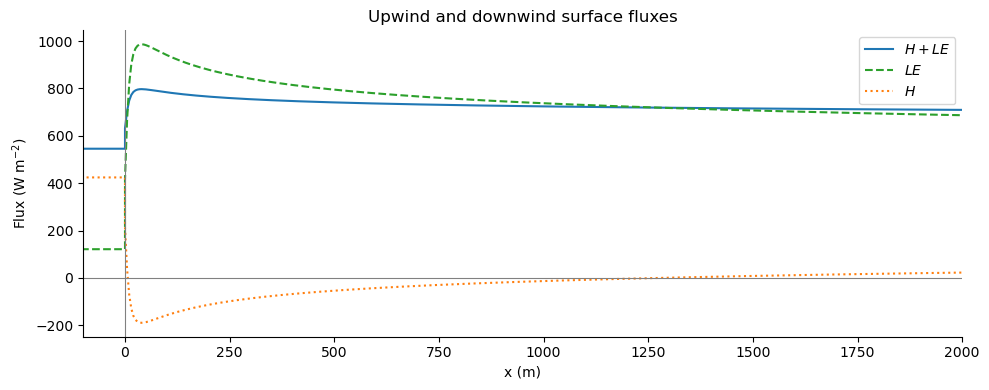

In [35]:
_level = 5  # reference height index, matching original notebook

fig, ax = plt.subplots(figsize=(10, 4))

xx = np.concatenate([-np.flip(x), x])

FluxTotal_upwind_1d = (LE_upwind_Wm2[_level] + H_upwind_Wm2[_level]) * np.ones_like(x)
FluxTotal_ = np.concatenate([FluxTotal_upwind_1d, FluxTotal[:, _level]])
LE_1d = np.concatenate([LE_upwind_Wm2[_level]*np.ones_like(x), LE_uniform_Wm2[:, _level]])
H_1d  = np.concatenate([H_upwind_Wm2[_level]*np.ones_like(x), H_uniform_Wm2[:, _level]])

ax.plot(xx, FluxTotal_, c='C0', ls='-',  label='$H + LE$')
ax.plot(xx, LE_1d,      c='C2', ls='--', label='$LE$')
ax.plot(xx, H_1d,       c='C1', ls=':',  label='$H$')
ax.axvline(0, c='grey', lw=0.8)
ax.axhline(0, c='grey', lw=0.8)
ax.set_xlim(-100, 2000)
ax.set_xlabel("x (m)")
ax.set_ylabel("Flux (W m$^{-2}$)")
ax.set_title("Upwind and downwind surface fluxes")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()


### Normalised ET vs fetch — Baldocchi & Rao (1995) Fig. 6

ET normalised by its far-downwind (equilibrium) value at x = 800 m.
The digitised data from Fig. 6 is overlaid as grey scatter points.


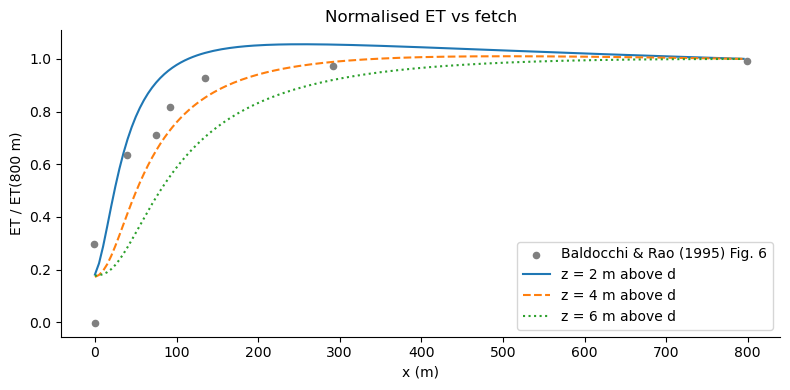

In [ ]:
fig6data = pd.read_csv('../data/baldocchi1995/baldocchi1995_fig6.csv')
fig6data.columns = fig6data.columns.str.strip()

d = h_canopy * 2/3  # zero-plane displacement

i800 = np.searchsorted(x, 800)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(fig6data['x'], fig6data['y'], c='grey', s=20,
           label="Baldocchi & Rao (1995) Fig. 6", zorder=5)

for level_h, ls in zip([2, 4, 6], ['-', '--', ':']):
    idx = np.argmin(np.abs(z - (level_h + d)))
    norm = FluxQ_uniform[i800, idx]
    if abs(norm) < 1e-12:
        continue
    ax.plot(x[:i800], FluxQ_uniform[:i800, idx] / norm,
            ls=ls, label=f"z = {level_h} m above d")

ax.set_xlabel("x (m)")
ax.set_ylabel("ET / ET(800 m)")
ax.set_title("Normalised ET vs fetch")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()


### Flux detail (0–500 m fetch)

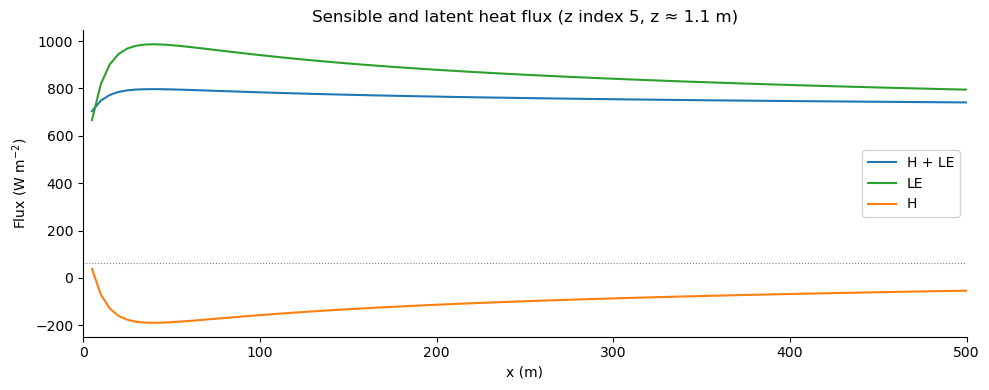

In [37]:
_level = 5

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x[1:], FluxTotal[1:, _level], label='H + LE', c='C0')
ax.plot(x[1:], LE_uniform_Wm2[1:, _level], label='LE', c='C2')
ax.plot(x[1:], H_uniform_Wm2[1:, _level], label='H', c='C1')
ax.axhline(H_uniform_Wm2[-1, _level], ls=':', c='grey', lw=0.8)
ax.set_xlim(0, 500)
ax.set_xlabel("x (m)")
ax.set_ylabel("Flux (W m$^{-2}$)")
ax.set_title(f"Sensible and latent heat flux (z index {_level}, z ≈ {z[_level]:.1f} m)")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()


### 2-D fields

Water-vapour concentration and vertical flux across the (x, z) domain.


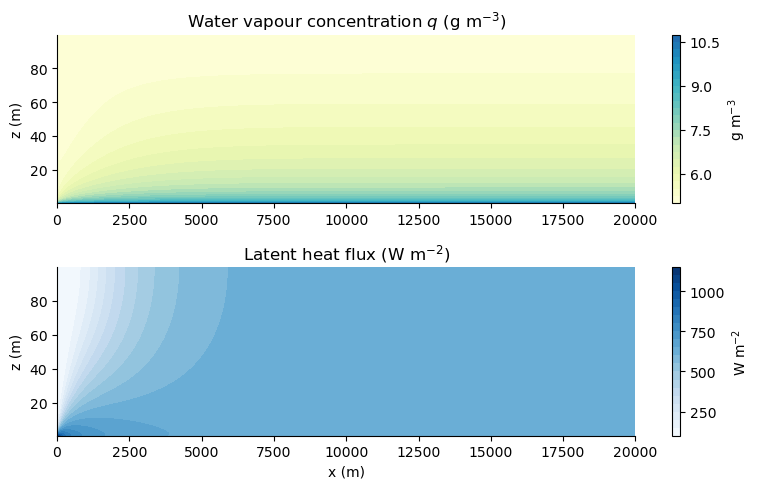

In [38]:
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

blues = ['#ffffd9','#edf8b1','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84']
custom_cmap = LinearSegmentedColormap.from_list('custom_blues', blues)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5))

# Q field
cf1 = ax1.contourf(x, z[1:], Q_uniform[:, 1:].T, 25, cmap=custom_cmap,
                    vmin=float(p.Q_a), vmax=float(p.Q_c))
cbar1 = fig.colorbar(cf1, ax=ax1, label='g m$^{-3}$')
cbar1.ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
ax1.set_ylabel("z (m)")
ax1.set_title("Water vapour concentration $q$ (g m$^{-3}$)")
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# LE field
cf2 = ax2.contourf(x, z[3:], (FluxQ_uniform[:, 3:].T * Lv_g).round(2), 20, cmap='Blues')
cbar2 = fig.colorbar(cf2, ax=ax2, label='W m$^{-2}$')
cbar2.ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
ax2.set_xlabel("x (m)")
ax2.set_ylabel("z (m)")
ax2.set_title("Latent heat flux (W m$^{-2}$)")
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
